## Land cover detection and moving windows
- Computing NDVI and NDWI with Landsat images 
- computing moving windows and study the correlations with LST depending on the size of the window.


### libraries and general paths

In [90]:
import os
import rasterio
from rasterio.mask import mask
from rasterio.warp import transform_geom
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import convolve

In [91]:
# user-defined paths
base_dir = '../../../datos-notebooks/3.global-data-cba/'
landsat_image = 'LC09_L2SP_229082_20240117_20240118_02_T1'
city_boundary = 'cba_boundary.gpkg'

# parameters for ndvi and ndwi classification
ndvi_dense_min = 0.29
ndvi_mid_min = 0.22
ndwi_true_min = 0.1

In [92]:
# derived paths

# Rasters
green_path = os.path.join(base_dir, 'land-cover/landsat-bands', f"{landsat_image}_SR_B3.TIF")
red_path   = os.path.join(base_dir, 'land-cover/landsat-bands', f"{landsat_image}_SR_B4.TIF")
nir_path   = os.path.join(base_dir, 'land-cover/landsat-bands', f"{landsat_image}_SR_B5.TIF")
lst_path   = os.path.join(base_dir, 'LST', f"{landsat_image}_ST_B10.tif")
lst_cropped_path = os.path.join(base_dir, 'LST/LST_cropped_celsius.tif') # values out of bound are 0
lst_clipped_path = os.path.join(base_dir, 'LST/LST_clipped_celsius.tif') #values out of bound are nan

# Boundary
bound = os.path.join(base_dir, 'vectors/',city_boundary)

# Folders
output_folder_ndvi = os.path.join(base_dir, 'land-cover/ndvi')   
os.makedirs(output_folder_ndvi, exist_ok=True)
output_folder_ndwi = os.path.join(base_dir, 'land-cover/ndwi')   
os.makedirs(output_folder_ndwi, exist_ok=True)
output_folder_mw = os.path.join(base_dir, 'land-cover/moving-windows')
os.makedirs(output_folder_mw, exist_ok=True)  
output_folder_mw_ndwi = os.path.join(output_folder_mw, "ndwi/")
os.makedirs(output_folder_mw_ndwi, exist_ok=True)
output_folder_mw_ndvi = os.path.join(output_folder_mw, "ndvi/")
os.makedirs(output_folder_mw_ndvi, exist_ok=True)

# Indexes
ndvi_path = f"{output_folder_ndvi}/ndvi.tif"
ndwi_path = f"{output_folder_ndwi}/ndwi.tif"

# Classified indexes
ndvi_1_path = f"{output_folder_ndvi}/ndvi_1.tif"
ndvi_0p5_path = f"{output_folder_ndvi}/ndvi_0p5.tif"
ndwi_1_path = f"{output_folder_ndwi}/ndwi_1.tif"

In [93]:
gdf = gpd.read_file(bound)

with rasterio.open(lst_path) as src:
    gdf= gdf.to_crs(src.crs)

### cropping and transforming the LST Image from Kelvin to Celsius

In [94]:
# --- Load, crop and transform LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # transformation
    lst_crop[lst_crop < 0] = np.nan # --- Assign nodata to LST < 0 --- (nodata is -124.15 now)

# save the result
with rasterio.open(
    lst_cropped_path,
    "w",
    driver="GTiff",
    height=lst_crop.shape[0],
    width=lst_crop.shape[1],
    count=1,
    dtype=lst_crop.dtype,
    crs=lst_crs,
    transform=lst_transform,
) as dst:
    dst.write(lst_crop, 1)

In [95]:
# Clip LST raster 

with rasterio.open(lst_cropped_path) as src:
    # Convert boundary to raster CRS
    boundary_crs = gdf.to_crs(src.crs)
    geoms = [boundary_crs.geometry.union_all().__geo_interface__]  # avoids deprecation warning

    # Clip raster to city boundary
    clipped_arr, clipped_transform = mask(
        src,
        geoms,
        crop=True,
        nodata=np.nan
    )

    # Convert to float and handle original nodata
    clipped_arr = clipped_arr.astype("float32")
    if src.nodata is not None:
        clipped_arr[clipped_arr == src.nodata] = np.nan

    # Remove extra dimensions
    clipped_arr = clipped_arr.squeeze()

    # Update metadata
    meta = src.meta.copy()
    meta.update({
        "height": clipped_arr.shape[0],
        "width": clipped_arr.shape[1],
        "transform": clipped_transform,
        "dtype": "float32",
        "nodata": np.nan
    })

# Save
with rasterio.open(lst_clipped_path, "w", **meta) as dst:
    dst.write(clipped_arr, 1)

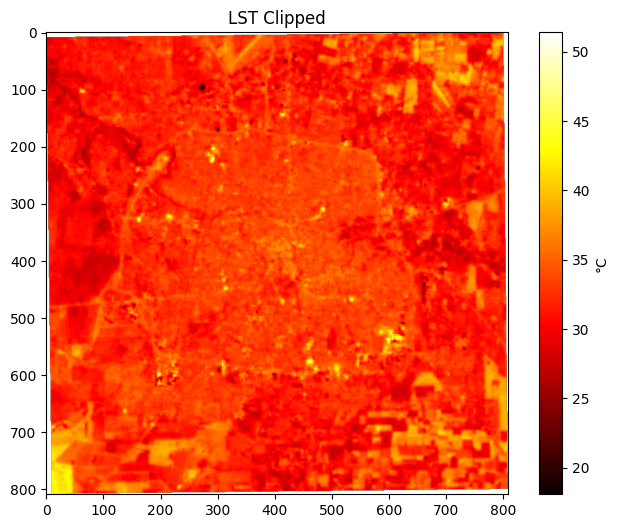

In [96]:
with rasterio.open(lst_clipped_path) as lst_crop:
    lst_crop = lst_crop.read(1)  
    
plt.figure(figsize=(8,6))
plt.imshow(lst_crop, cmap='hot')  
plt.colorbar(label='°C')
plt.title('LST Clipped')
plt.show()

###  Cropping images and computing NDVI, NDWI

In [97]:
# Get LST extent + metadata for outputs
with rasterio.open(lst_cropped_path) as lst_src:
    lst_bounds = lst_src.bounds
    lst_geom = [{
        "type": "Polygon",
        "coordinates": [[
            (lst_bounds.left,  lst_bounds.bottom),
            (lst_bounds.left,  lst_bounds.top),
            (lst_bounds.right, lst_bounds.top),
            (lst_bounds.right, lst_bounds.bottom),
            (lst_bounds.left,  lst_bounds.bottom)
        ]]
    }]
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype="float32", count=1, nodata=np.nan)

# get geometry for cropping
lst_geom = [{
    "type": "Polygon",
    "coordinates": [[
        (lst_bounds.left,  lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.top),
        (lst_bounds.right, lst_bounds.top),
        (lst_bounds.right, lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.bottom)
    ]]
}]

In [98]:
# Crop 
def crop_band(path, geom):
    """Crop band to LST extent"""
    with rasterio.open(path) as src:
        data, _ = mask(src, geom, crop=True)
        return data[0].astype("float32")

green = crop_band(green_path, lst_geom)
red   = crop_band(red_path,   lst_geom)
nir   = crop_band(nir_path,   lst_geom)

np.seterr(divide="ignore", invalid="ignore")

# Indices
ndvi = (nir - red) / (nir + red)
ndwi = (green - nir) / (green + nir) 

# Save outputs
with rasterio.open(ndvi_path, "w", **out_meta) as dst:
    dst.write(ndvi.astype("float32"), 1)

with rasterio.open(ndwi_path, "w", **out_meta) as dst:
    dst.write(ndwi.astype("float32"), 1)


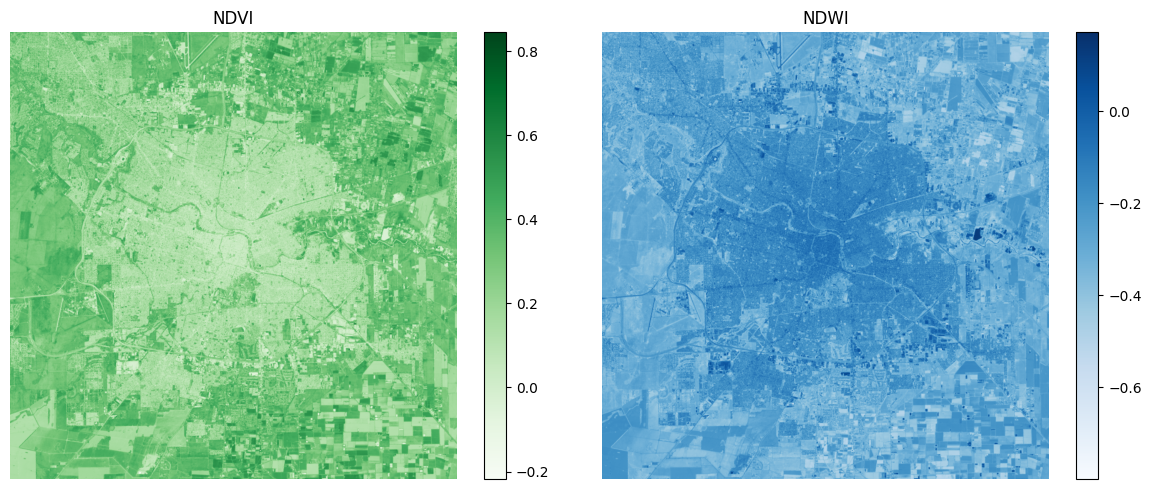

In [99]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# NDVI
im1 = axs[0].imshow(ndvi, cmap="Greens")
axs[0].set_title("NDVI")
axs[0].axis("off")
plt.colorbar(im1, ax=axs[0], fraction=0.046)

# NDWI
im2 = axs[1].imshow(ndwi, cmap="Blues")
axs[1].set_title("NDWI")
axs[1].axis("off")
plt.colorbar(im2, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()


#### classifying values

In [100]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

ndvi_1 = np.where(ndvi > ndvi_dense_min, 1, 0).astype('float32')
ndvi_0p5 = np.where((ndvi > ndvi_mid_min) & (ndvi <= ndvi_dense_min),1,0).astype('float32')
ndwi_1 = np.where(ndwi > ndwi_true_min, 1, 0).astype('float32')

# Save outputs
with rasterio.open(lst_cropped_path) as lst_src:
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype="float32", count=1, nodata=np.nan)

with rasterio.open(ndvi_1_path, "w", **out_meta) as dst:
    dst.write(ndvi_1.astype("float32"), 1)
    
with rasterio.open(ndvi_0p5_path, "w", **out_meta) as dst:
    dst.write(ndvi_0p5.astype("float32"), 1)

with rasterio.open(ndwi_1_path, "w", **out_meta) as dst:
    dst.write(ndwi_1.astype("float32"), 1)

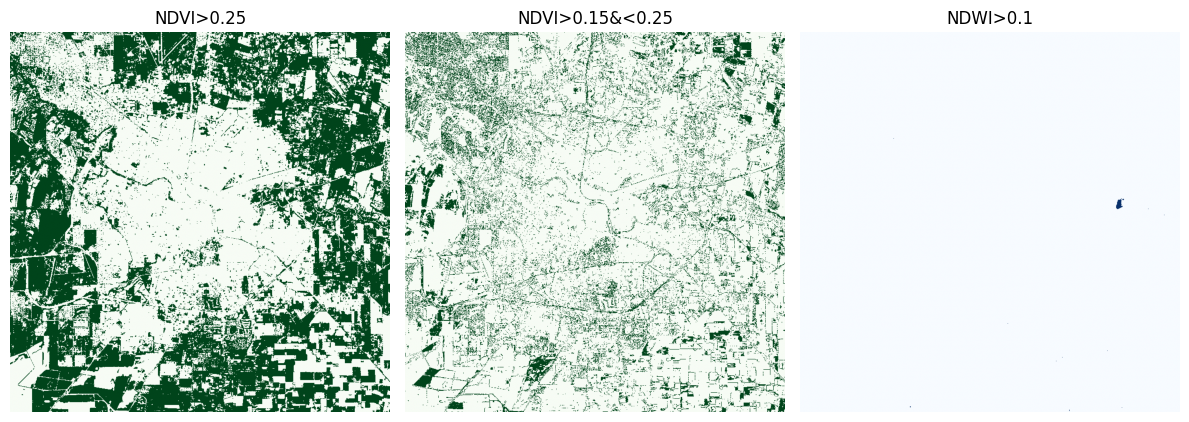

In [101]:
with rasterio.open(ndvi_1_path) as src:
    ndvi_1 = src.read(1).astype(np.float32)

with rasterio.open(ndvi_0p5_path) as src:
    ndvi_0p5 = src.read(1).astype(np.float32)

with rasterio.open(ndwi_1_path) as src:
    ndwi_1 = src.read(1).astype(np.float32)

fig, axs = plt.subplots(1, 3, figsize=(12, 5))

# NDVI_1
im1 = axs[0].imshow(ndvi_1, cmap="Greens")
axs[0].set_title("NDVI>0.25")
axs[0].axis("off")

# NDVI_0.5
im1 = axs[1].imshow(ndvi_0p5, cmap="Greens")
axs[1].set_title("NDVI>0.15&<0.25")
axs[1].axis("off")

# NDWI
im2 = axs[2].imshow(ndwi_1, cmap="Blues")
axs[2].set_title("NDWI>0.1")
axs[2].axis("off")

plt.tight_layout()
plt.show()


### moving windows 

In [102]:
def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1, "Window size must be odd"
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4  # controls smoothing strength
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()  # normalize to sum=1
    return weights


def moving_window_weighted(array, kernel):
    """Apply distance-weighted convolution."""
    return convolve(array, kernel, mode='nearest')


#### NDVI

In [103]:
ndvi_paths = {
    "class_1": ndvi_1_path,
    "class_0p5": ndvi_0p5_path,
}    

In [104]:
# Loop over classes
for class_name, path in ndvi_paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile

        # Loop over window sizes (ONLY odd sizes)
        for window_size in range(1, 101, 2):  
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

            # Save raster
            out_profile = profile.copy()
            out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
            out_path = os.path.join(
                output_folder_mw_ndvi, 
                f"{class_name}_window{window_size}.tif"
            )

            with rasterio.open(out_path, "w", **out_profile) as dst:
                dst.write(smoothed.astype(np.float32), 1)


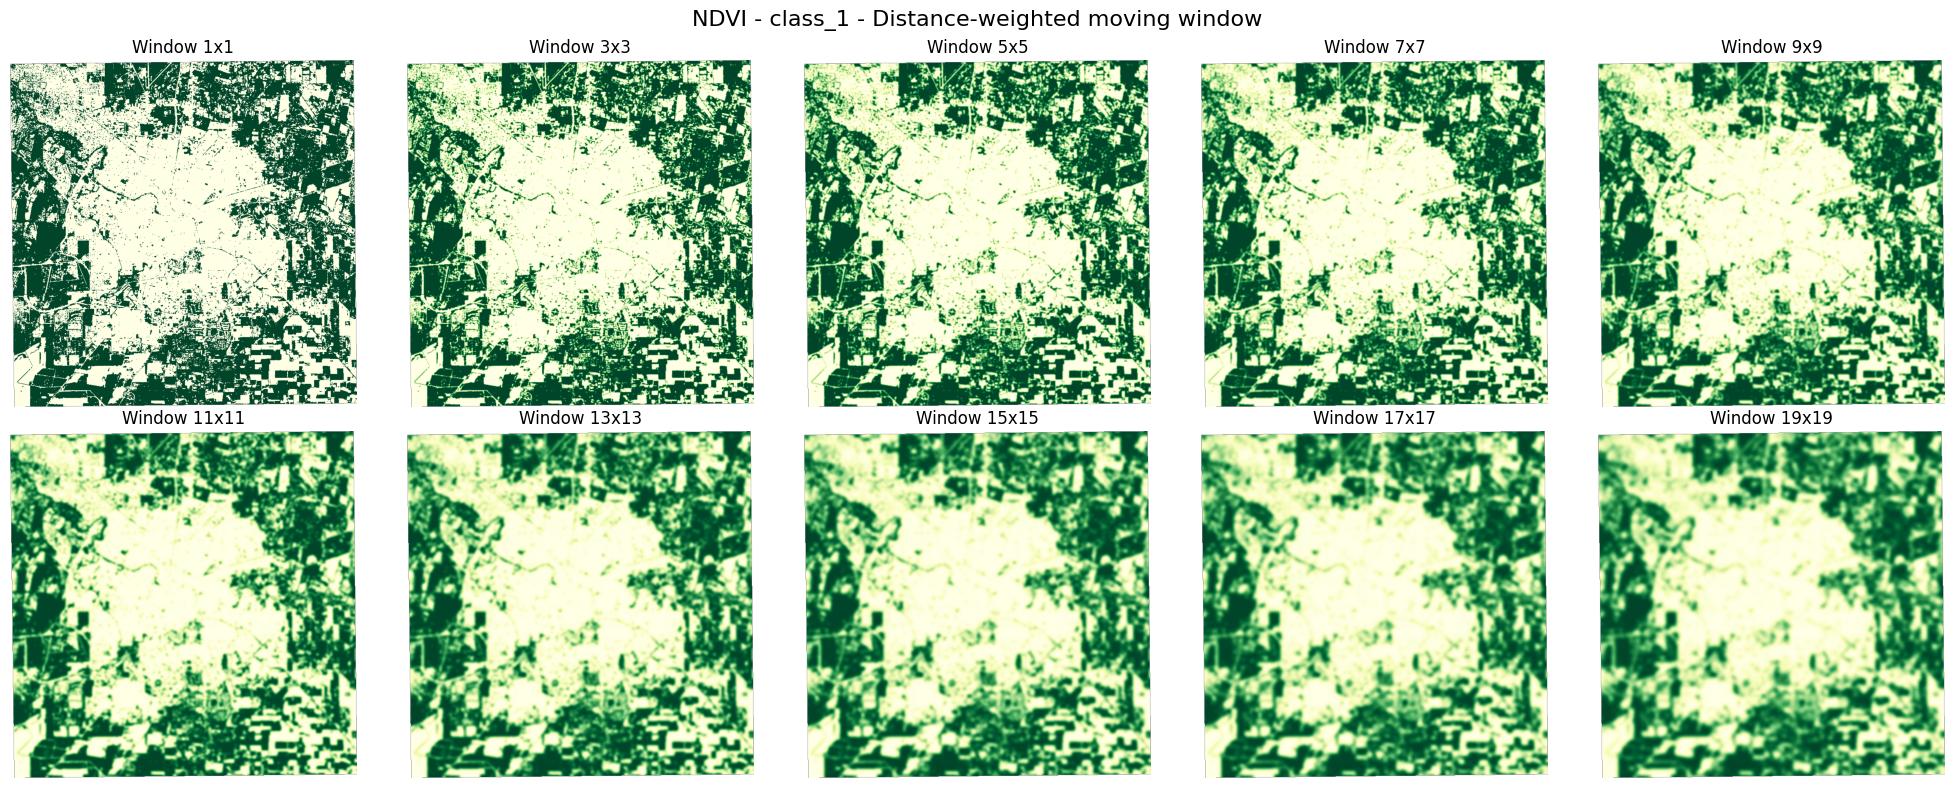

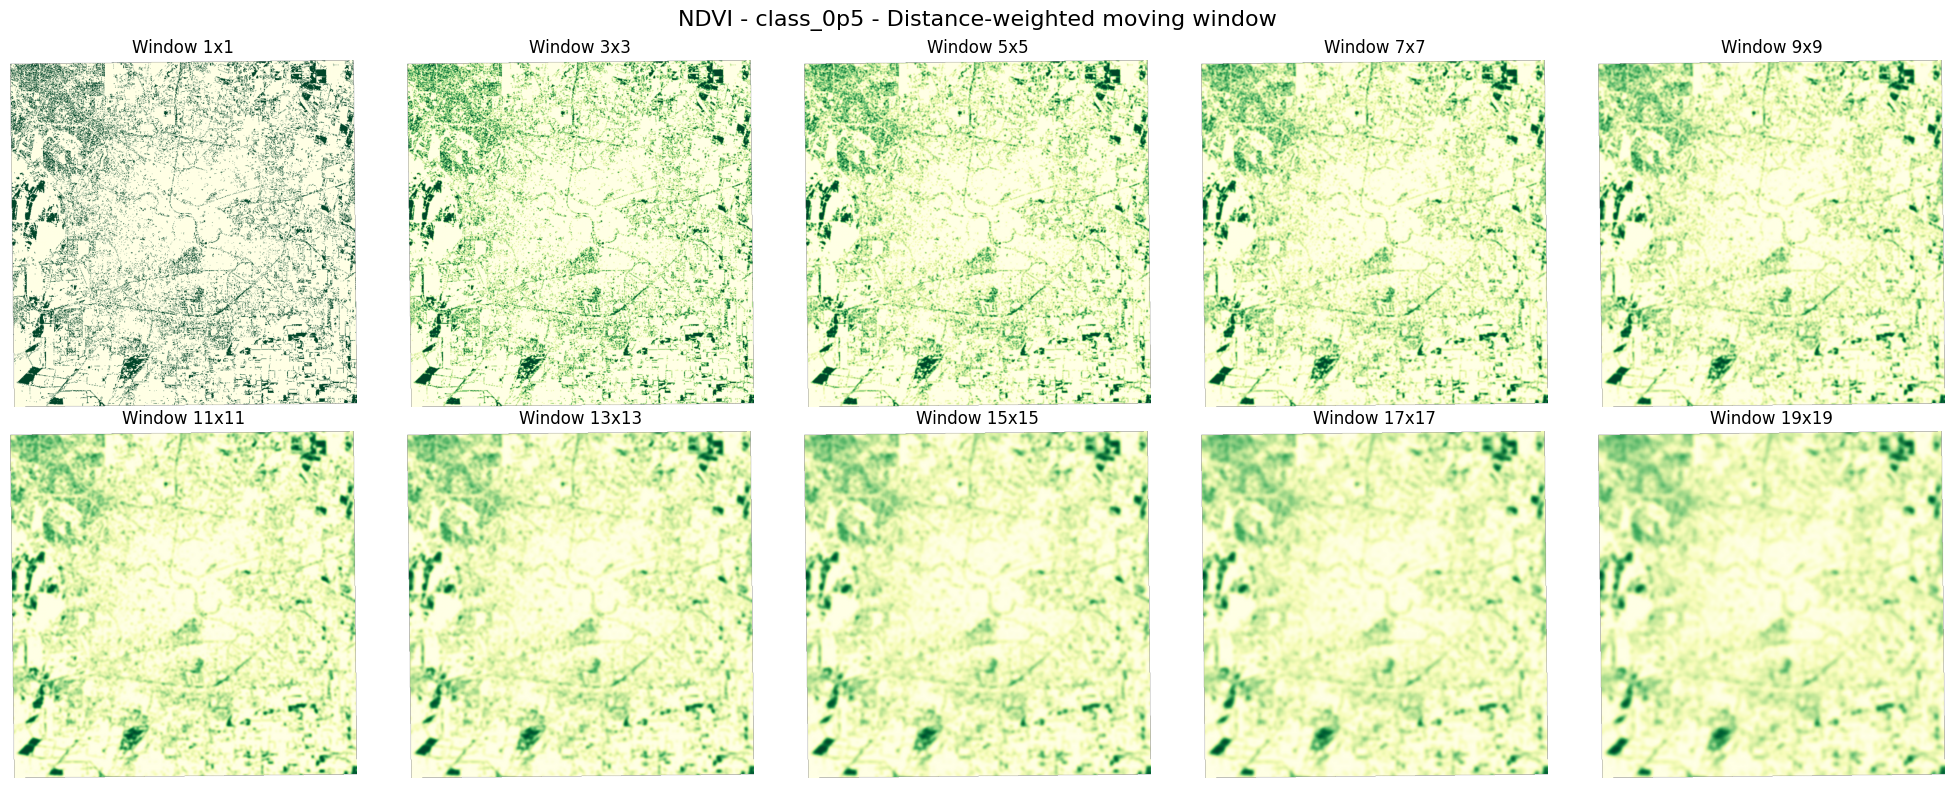

In [105]:
classes = ["class_1", "class_0p5"]

window_sizes = list(range(1, 21, 2))  # odd windows

for class_name in classes:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8)) 
    axes = axes.flatten()

    for ax, w in zip(axes, window_sizes):
        raster_path = os.path.join(
            output_folder_mw_ndvi, 
            f"{class_name}_window{w}.tif"
        )

        with rasterio.open(raster_path) as src:
            data, _ = mask(src, gdf.geometry, crop=True) #crop the plot
            data = data[0]

        im = ax.imshow(data, cmap="YlGn")
        ax.set_title(f"Window {w}x{w}")
        ax.axis("off")

    fig.suptitle(f"NDVI - {class_name} - Distance-weighted moving window", fontsize=16)
    plt.tight_layout()
    plt.show()



#### NDWI

In [106]:
with rasterio.open(ndwi_1_path) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    # Loop over window sizes (only odd sizes)
    for window_size in range(1, 101, 2):  
        kernel = distance_weighted_kernel(window_size)
        smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            output_folder_mw_ndwi, 
            f"class_1_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)


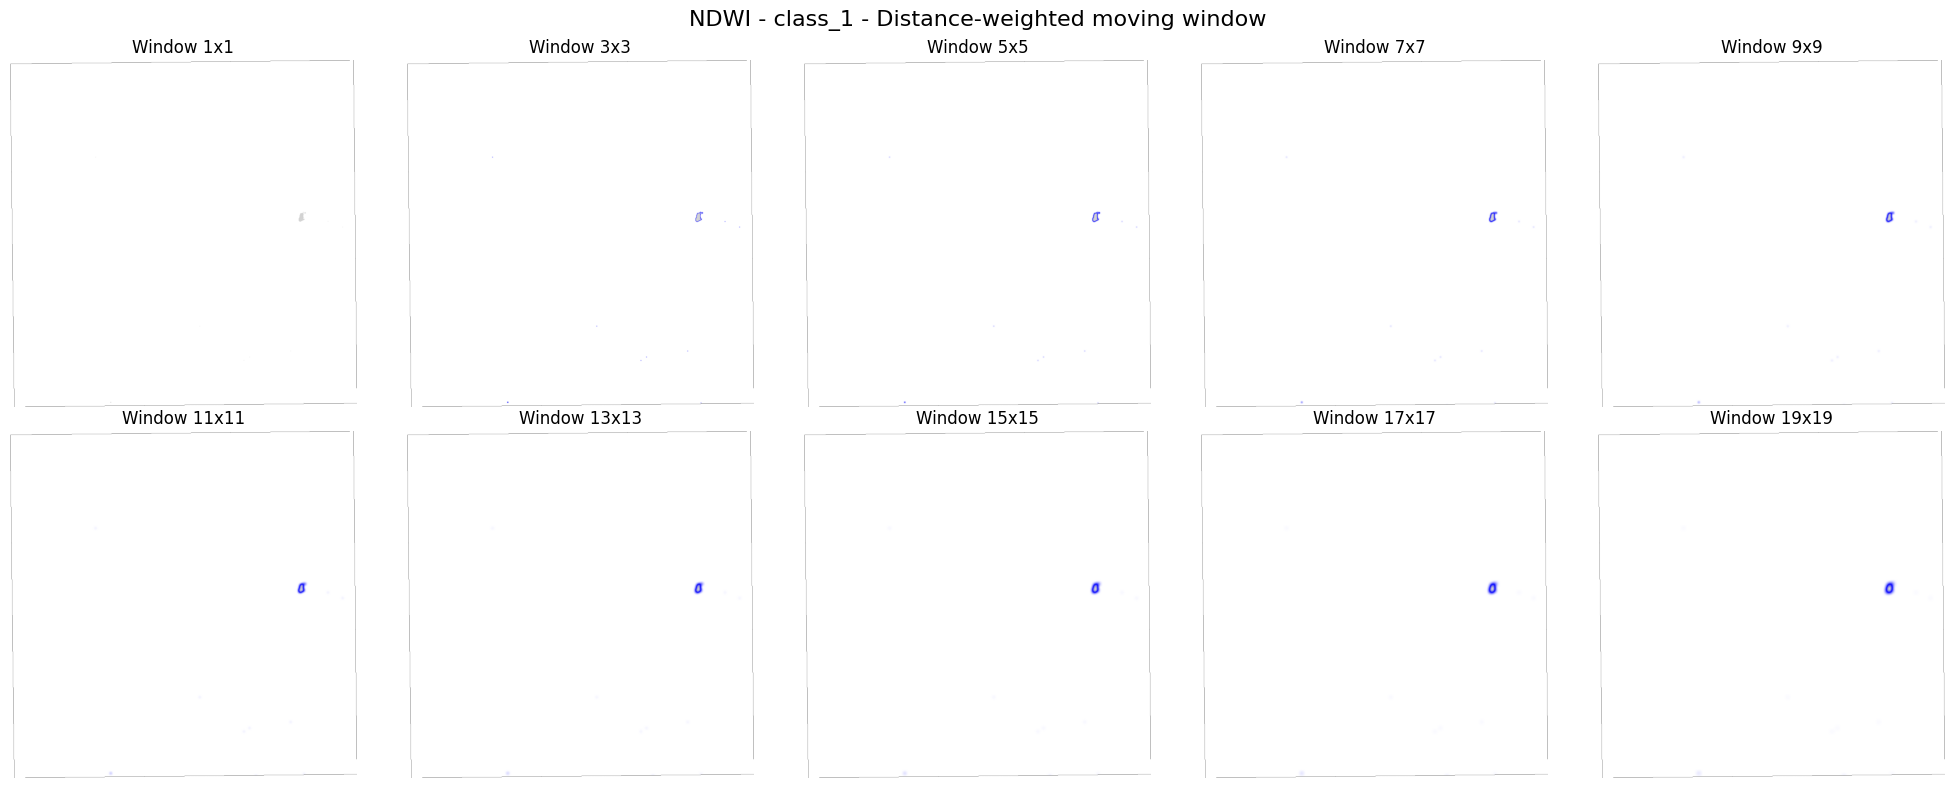

In [107]:
# Define custom colormap
colors = ["white", "blue", "lightgrey"]
custom_cmap = LinearSegmentedColormap.from_list("white_blue_purple", colors)

window_sizes = list(range(1, 21, 2))  # odd windows only 

fig, axes = plt.subplots(2, 5, figsize=(20, 8)) 
axes = axes.flatten()

for ax, w in zip(axes, window_sizes):
    raster_path = os.path.join(
        output_folder_mw_ndwi, 
        f"class_1_window{w}.tif"
    )
    with rasterio.open(raster_path) as src:
        data, _ = mask(src, gdf.geometry, crop=True)
        data = data[0]

        im = ax.imshow(data, cmap=custom_cmap)
        ax.set_title(f"Window {w}x{w}")
        ax.axis("off")

fig.suptitle(f"NDWI - class_1 - Distance-weighted moving window", fontsize=16)
plt.tight_layout()
plt.show()


### Correlations with LST

In [108]:
# general parameters
window_sizes = range(1, 101, 2)

# --- Load LST ---
with rasterio.open(lst_clipped_path) as lst:
    lst_crs = lst.crs
    lst_clip = lst.read(1)          
    lst_transform = lst.transform   

#### NDVI-LST

##### CLASS 1 (dense vegetation)

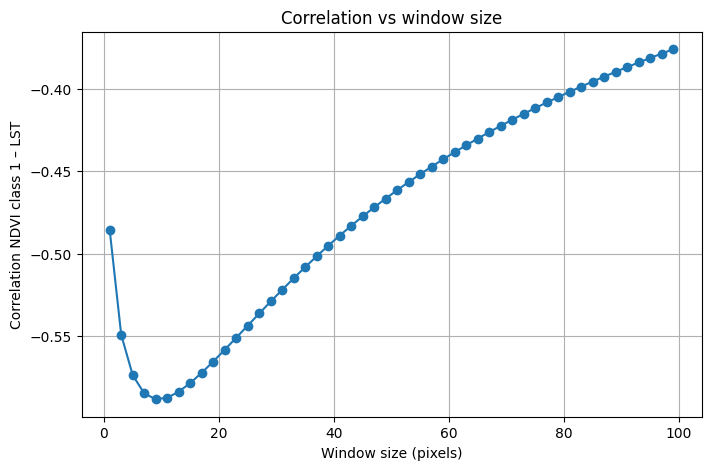

In [109]:
correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(output_folder_mw_ndvi, f"class_1_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    
    # Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 1 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()


##### Class 0.5 (mid vegetation)

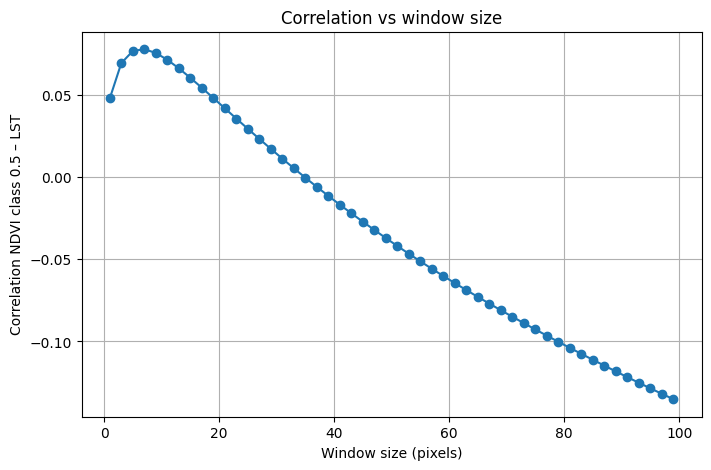

In [110]:
correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(output_folder_mw_ndvi, f"class_0p5_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 0.5 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()


#### NDWI-LST

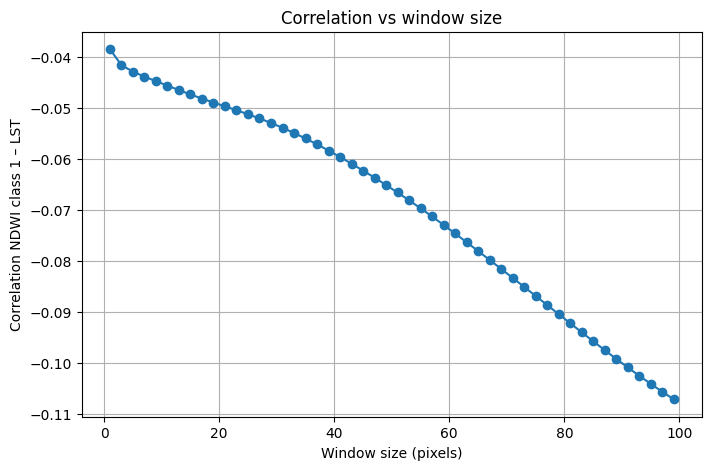

In [111]:
window_sizes = range(1, 101, 2)

correlations = []

for w in window_sizes:
    ndwi_path = os.path.join(output_folder_mw_ndwi, f"class_1_window{w}.tif")
    with rasterio.open(ndwi_path) as src_ndwi:
        gdf_ndwi = gdf.to_crs(src_ndwi.crs)
        ndwi_crop, ndwi_transform = mask(src_ndwi, gdf_ndwi.geometry, crop=True)
        ndwi_crop = ndwi_crop[0].astype(float)

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  
    ndwi_vals = ndwi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndwi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDWI class 1 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()

### estudiando otras img lst

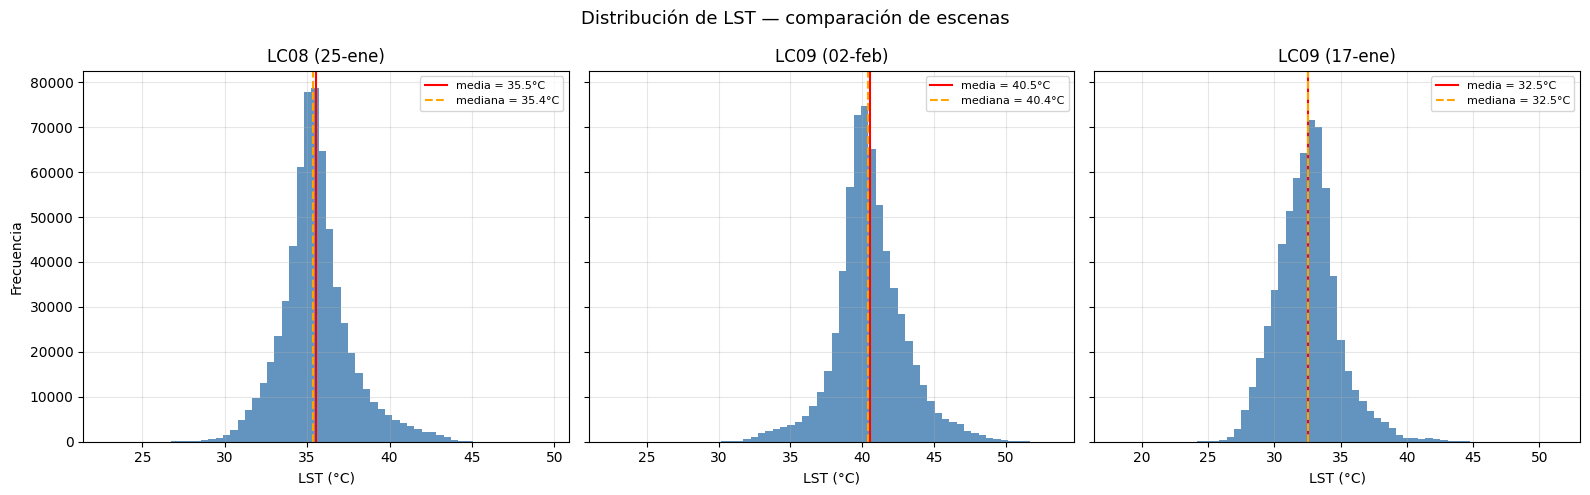

In [112]:
# Histogramas comparativos de LST — 3 imágenes

scenes = {
    'LC08 (25-ene)': os.path.join(base_dir, 'LST', 'LC08_L2SP_229082_20240125_20240130_02_T1_ST_B10.tif'),
    'LC09 (02-feb)': os.path.join(base_dir, 'LST', 'LC09_L2SP_229082_20240202_20240205_02_T1_ST_B10.tif'),
    'LC09 (17-ene)': os.path.join(base_dir, 'LST', 'LC09_L2SP_229082_20240117_20240118_02_T1_ST_B10.tif'),
}

fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (label, path) in zip(axs, scenes.items()):
    with rasterio.open(path) as src:
        gdf_r = gdf.to_crs(src.crs)
        arr, _ = mask(src, gdf_r.geometry, crop=True)
        arr = arr[0].astype('float32')
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan

    # K → °C
    arr = arr * 0.00341802 - 124.15
    arr[arr < 0] = np.nan

    vals = arr[~np.isnan(arr)]

    ax.hist(vals, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(np.nanmean(arr), color='red',    linewidth=1.5, label=f'media = {np.nanmean(arr):.1f}°C')
    ax.axvline(np.nanmedian(arr), color='orange', linewidth=1.5, linestyle='--', label=f'mediana = {np.nanmedian(arr):.1f}°C')
    ax.set_title(label)
    ax.set_xlabel('LST (°C)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axs[0].set_ylabel('Frecuencia')
plt.suptitle('Distribución de LST — comparación de escenas', fontsize=13)
plt.tight_layout()
plt.show()

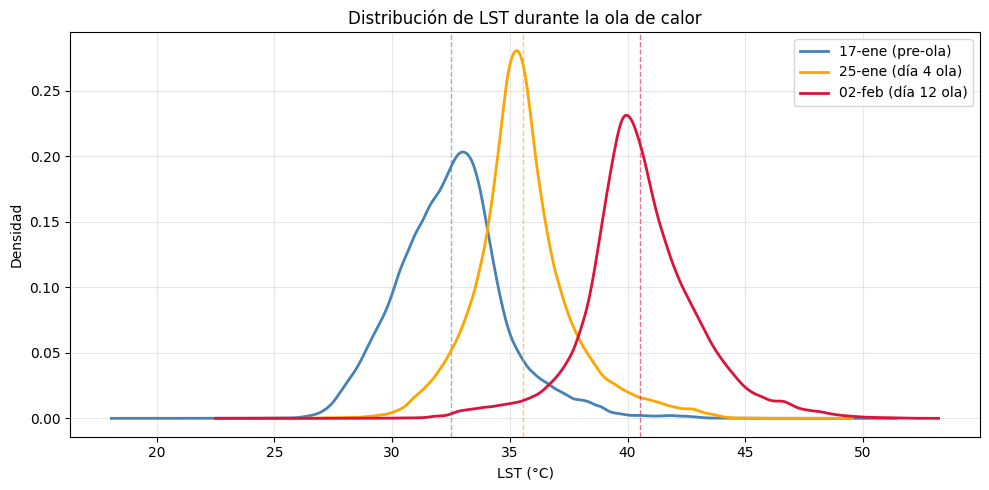

Escena                      Media    Std    IQR    P25    P75
-------------------------------------------------------
17-ene (pre-ola)            32.53   2.31   2.78  31.01  33.79
25-ene (día 4 ola)          35.55   2.13   2.13  34.38  36.51
02-feb (día 12 ola)         40.55   2.47   2.62  39.23  41.85


In [113]:
from scipy.stats import gaussian_kde

scenes = {
    '17-ene (pre-ola)':       os.path.join(base_dir, 'LST', 'LC09_L2SP_229082_20240117_20240118_02_T1_ST_B10.tif'),
    '25-ene (día 4 ola)':     os.path.join(base_dir, 'LST', 'LC08_L2SP_229082_20240125_20240130_02_T1_ST_B10.tif'),
    '02-feb (día 12 ola)':    os.path.join(base_dir, 'LST', 'LC09_L2SP_229082_20240202_20240205_02_T1_ST_B10.tif'),
}

colors = ['steelblue', 'orange', 'crimson']
stats  = {}

fig, ax = plt.subplots(figsize=(10, 5))

for (label, path), color in zip(scenes.items(), colors):
    with rasterio.open(path) as src:
        gdf_r = gdf.to_crs(src.crs)
        arr, _ = mask(src, gdf_r.geometry, crop=True)
        arr = arr[0].astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

    arr = arr * 0.00341802 - 124.15
    arr[arr < 0] = np.nan
    vals = arr[~np.isnan(arr)]

    # KDE
    kde  = gaussian_kde(vals)
    x    = np.linspace(vals.min(), vals.max(), 500)
    ax.plot(x, kde(x), color=color, linewidth=2, label=label)
    ax.axvline(np.mean(vals), color=color, linewidth=1, linestyle='--', alpha=0.6)

    stats[label] = {
        'media':    np.mean(vals),
        'std':      np.std(vals),
        'iqr':      np.percentile(vals, 75) - np.percentile(vals, 25),
        'p25':      np.percentile(vals, 25),
        'p75':      np.percentile(vals, 75),
    }

ax.set_xlabel('LST (°C)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de LST durante la ola de calor')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla de estadísticos
print(f"{'Escena':<25} {'Media':>7} {'Std':>6} {'IQR':>6} {'P25':>6} {'P75':>6}")
print('-' * 55)
for label, s in stats.items():
    print(f"{label:<25} {s['media']:>7.2f} {s['std']:>6.2f} {s['iqr']:>6.2f} {s['p25']:>6.2f} {s['p75']:>6.2f}")

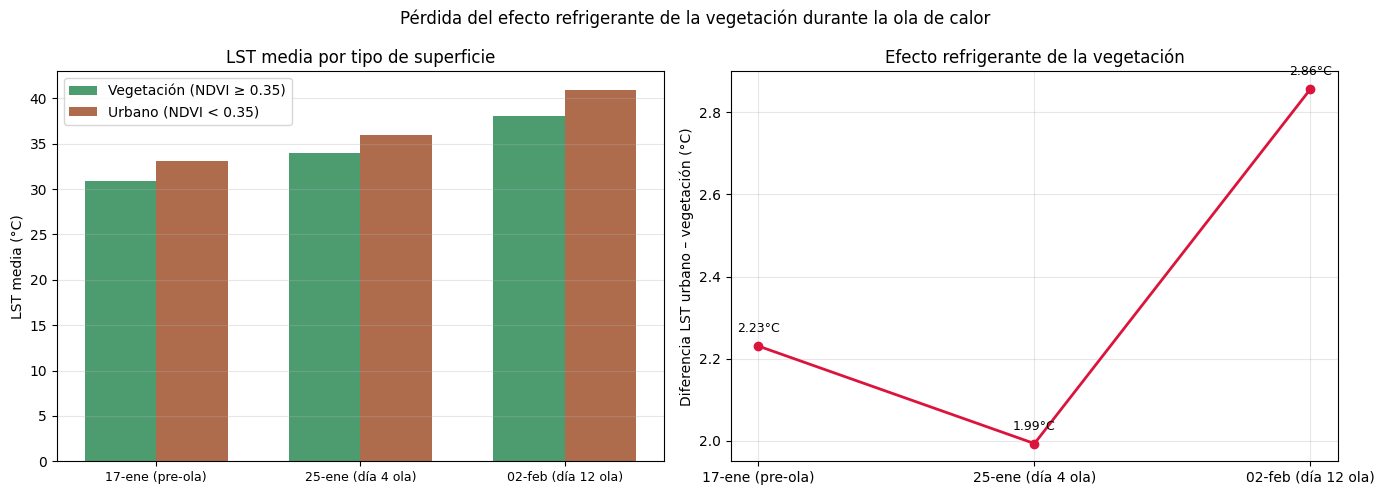

Escena                      LST veg   LST urb  Diferencia
----------------------------------------------------------
17-ene (pre-ola)              30.86     33.09        2.23
25-ene (día 4 ola)            33.96     35.96        1.99
02-feb (día 12 ola)           38.07     40.92        2.86


In [114]:
from scipy.stats import gaussian_kde

scenes = {
    '17-ene (pre-ola)': {
        'lst': os.path.join(base_dir, 'LST', 'LC09_L2SP_229082_20240117_20240118_02_T1_ST_B10.tif'),
        'b4':  os.path.join(base_dir, 'land-cover/landsat-bands', 'LC09_L2SP_229082_20240117_20240118_02_T1_SR_B4.TIF'),
        'b5':  os.path.join(base_dir, 'land-cover/landsat-bands', 'LC09_L2SP_229082_20240117_20240118_02_T1_SR_B5.TIF'),
    },
    '25-ene (día 4 ola)': {
        'lst': os.path.join(base_dir, 'LST', 'LC08_L2SP_229082_20240125_20240130_02_T1_ST_B10.tif'),
        'b4':  os.path.join(base_dir, 'land-cover/landsat-bands', 'LC08_L2SP_229082_20240125_20240130_02_T1_SR_B4.TIF'),
        'b5':  os.path.join(base_dir, 'land-cover/landsat-bands', 'LC08_L2SP_229082_20240125_20240130_02_T1_SR_B5.TIF'),
    },
    '02-feb (día 12 ola)': {
        'lst': os.path.join(base_dir, 'LST', 'LC09_L2SP_229082_20240202_20240205_02_T1_ST_B10.tif'),
        'b4':  os.path.join(base_dir, 'land-cover/landsat-bands', 'LC09_L2SP_229082_20240202_20240205_02_T1_SR_B4.TIF'),
        'b5':  os.path.join(base_dir, 'land-cover/landsat-bands', 'LC09_L2SP_229082_20240202_20240205_02_T1_SR_B5.TIF'),
    },
}

ndvi_threshold = 0.35  # umbral para "vegetación densa"
colors = ['steelblue', 'orange', 'crimson']
results = {}

def load_crop(path, gdf):
    with rasterio.open(path) as src:
        gdf_r = gdf.to_crs(src.crs)
        arr, _ = mask(src, gdf_r.geometry, crop=True)
        arr = arr[0].astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr

for label, paths in scenes.items():
    lst  = load_crop(paths['lst'], gdf) * 0.00341802 - 124.15
    lst[lst < 0] = np.nan
    red  = load_crop(paths['b4'], gdf)
    nir  = load_crop(paths['b5'], gdf)

    np.seterr(divide='ignore', invalid='ignore')
    ndvi = (nir - red) / (nir + red)

    # Alinear shapes
    min_r = min(lst.shape[0], ndvi.shape[0])
    min_c = min(lst.shape[1], ndvi.shape[1])
    lst  = lst[:min_r, :min_c]
    ndvi = ndvi[:min_r, :min_c]

    valid     = ~(np.isnan(lst) | np.isnan(ndvi))
    veg_mask  = valid & (ndvi >= ndvi_threshold)
    urb_mask  = valid & (ndvi <  ndvi_threshold)

    results[label] = {
        'lst_veg':  lst[veg_mask],
        'lst_urb':  lst[urb_mask],
        'mean_veg': np.mean(lst[veg_mask]),
        'mean_urb': np.mean(lst[urb_mask]),
        'diff':     np.mean(lst[urb_mask]) - np.mean(lst[veg_mask]),
    }

# --- Plot 1: diferencia vegetación vs urbano por escena ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

labels = list(results.keys())
diffs  = [results[l]['diff']     for l in labels]
vegm   = [results[l]['mean_veg'] for l in labels]
urbm   = [results[l]['mean_urb'] for l in labels]

x = np.arange(len(labels))
width = 0.35

axs[0].bar(x - width/2, vegm, width, label='Vegetación (NDVI ≥ 0.35)', color='seagreen',   alpha=0.85)
axs[0].bar(x + width/2, urbm, width, label='Urbano (NDVI < 0.35)',      color='sienna', alpha=0.85)
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels, fontsize=9)
axs[0].set_ylabel('LST media (°C)')
axs[0].set_title('LST media por tipo de superficie')
axs[0].legend()
axs[0].grid(True, alpha=0.3, axis='y')

axs[1].plot(labels, diffs, marker='o', color='crimson', linewidth=2)
for i, (l, d) in enumerate(zip(labels, diffs)):
    axs[1].annotate(f'{d:.2f}°C', (l, d), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
axs[1].set_ylabel('Diferencia LST urbano – vegetación (°C)')
axs[1].set_title('Efecto refrigerante de la vegetación')
axs[1].grid(True, alpha=0.3)

plt.suptitle('Pérdida del efecto refrigerante de la vegetación durante la ola de calor', fontsize=12)
plt.tight_layout()
plt.show()

# Tabla resumen
print(f"{'Escena':<25} {'LST veg':>9} {'LST urb':>9} {'Diferencia':>11}")
print('-' * 58)
for l in labels:
    r = results[l]
    print(f"{l:<25} {r['mean_veg']:>9.2f} {r['mean_urb']:>9.2f} {r['diff']:>11.2f}")